# Importing libraries

In [144]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the Dataset

In [145]:
df=pd.read_csv('titanic.csv')

# Understanding the data

In [146]:
df.columns
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    object 
 9   embarked  1307 non-null   object 
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


# Data Cleaning

In [147]:
df.duplicated().any()

np.False_

In [148]:
age_mean=df['age'].mean()
fare_mean=df['fare'].mean()
emb_mode=df['embarked'].mode()[0]
df['age']=df['age'].fillna(age_mean)   
df['fare']=df['fare'].fillna(fare_mean)  
df['embarked']=df['embarked'].fillna(emb_mode)  
df=df.drop(columns=['cabin'])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1309 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1309 non-null   float64
 8   embarked  1309 non-null   object 
 9   survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 102.4+ KB


# data Transformation /feature Engineering

In [149]:
df['age']=df['age'].round(1)   
df['fare']=df['fare'].round(1)

In [150]:
df['family_cnt']=df['sibsp']+df['parch']
df=df.drop(columns=['sibsp','parch'])


In [151]:
df['embarked'].unique()
df['embarked']=df['embarked'].replace({'C':'Cherbourg','Q':'Queenstown','S':'Southampton'})

In [152]:
df=df.rename(columns={'sex':'gender',})

In [153]:
df['gender']=df['gender'].str.title()

In [154]:
df[['Last_name', 'rest']] = df['name'].str.split(',', n=1, expand=True)
df['Last_name'] = df['Last_name'].str.strip()
df['rest'] = df['rest'].str.strip()
df[['Title', 'First_Name']] = df['rest'].str.split(' ', n=1, expand=True)
df['Title'] = df['Title'].str.replace(r'\.$', '', regex=True)
df = df.drop(columns='rest')
df

,pclass,name,gender,age,ticket,fare,embarked,survived,family_cnt,Last_name,Title,First_Name
0,1,"Allen, Miss. Elisabeth Walton",Female,29.0,24160,211.3,Southampton,1,0,Allen,Miss,Elisabeth Walton
1,1,"Allison, Master. Hudson Trevor",Male,0.9,113781,151.6,Southampton,1,3,Allison,Master,Hudson Trevor
2,1,"Allison, Miss. Helen Loraine",Female,2.0,113781,151.6,Southampton,0,3,Allison,Miss,Helen Loraine
3,1,"Allison, Mr. Hudson Joshua Creighton",Male,30.0,113781,151.6,Southampton,0,3,Allison,Mr,Hudson Joshua Creighton
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",Female,25.0,113781,151.6,Southampton,0,3,Allison,Mrs,Hudson J C (Bessie Waldo Daniels)
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",Female,14.5,2665,14.5,Cherbourg,0,1,Zabour,Miss,Hileni
1305,3,"Zabour, Miss. Thamine",Female,29.9,2665,14.5,Cherbourg,0,1,Zabour,Miss,Thamine
1306,3,"Zakarian, Mr. Mapriededer",Male,26.5,2656,7.2,Cherbourg,0,0,Zakarian,Mr,Mapriededer
1307,3,"Zakarian, Mr. Ortin",Male,27.0,2670,7.2,Cherbourg,0,0,Zakarian,Mr,Ortin


In [155]:
g=df['ticket'].value_counts()
solo_ticket=g[g==1].index
def f1(d):
    if d['family_cnt']>0 :
        return 'Family'
    else:
        if d['ticket'] in (solo_ticket):
            return 'solo'
        else:
         return "Friends"

In [156]:
df['Companion_type']=df.apply(f1,axis=1)
df

,pclass,name,gender,age,ticket,fare,embarked,survived,family_cnt,Last_name,Title,First_Name,Companion_type
0,1,"Allen, Miss. Elisabeth Walton",Female,29.0,24160,211.3,Southampton,1,0,Allen,Miss,Elisabeth Walton,Friends
1,1,"Allison, Master. Hudson Trevor",Male,0.9,113781,151.6,Southampton,1,3,Allison,Master,Hudson Trevor,Family
2,1,"Allison, Miss. Helen Loraine",Female,2.0,113781,151.6,Southampton,0,3,Allison,Miss,Helen Loraine,Family
3,1,"Allison, Mr. Hudson Joshua Creighton",Male,30.0,113781,151.6,Southampton,0,3,Allison,Mr,Hudson Joshua Creighton,Family
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",Female,25.0,113781,151.6,Southampton,0,3,Allison,Mrs,Hudson J C (Bessie Waldo Daniels),Family
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",Female,14.5,2665,14.5,Cherbourg,0,1,Zabour,Miss,Hileni,Family
1305,3,"Zabour, Miss. Thamine",Female,29.9,2665,14.5,Cherbourg,0,1,Zabour,Miss,Thamine,Family
1306,3,"Zakarian, Mr. Mapriededer",Male,26.5,2656,7.2,Cherbourg,0,0,Zakarian,Mr,Mapriededer,solo
1307,3,"Zakarian, Mr. Ortin",Male,27.0,2670,7.2,Cherbourg,0,0,Zakarian,Mr,Ortin,solo


In [157]:
lst=['ticket','Title','First_Name','Last_name', 'gender','age','Companion_type','family_cnt','pclass','embarked', 'fare','survived']
df=df[lst]

In [158]:
df['age_cat']=pd.cut(df['age'],bins=[0,15,25,60,81],labels=['child','teen','adult','senior'])

# level-1

1. get the unique values for (gender,pclass,age_category,companion_type,embarked)
   

In [159]:
print(df['gender'].unique())
print(df['pclass'].unique())
print(df['age_cat'].unique())
print(df['Companion_type'].unique())
print(df['embarked'].unique())

['Female' 'Male']
[1 2 3]
['adult', 'child', 'teen', 'senior']
Categories (4, object): ['child' < 'teen' < 'adult' < 'senior']
['Friends' 'Family' 'solo']
['Southampton' 'Cherbourg' 'Queenstown']


2. (i)  get the passenger 'Emil' details

   (ii) get the passenger 'Emil' gender,age,companion_type,survival_status

In [160]:
df.query("First_Name=='Emil'")
df.loc[df['First_Name']=="Emil",['gender','age','Companion_type','survived']]


,gender,age,Companion_type,survived
39,Male,48.0,solo,0
290,Male,52.0,Family,0
715,Male,29.0,solo,0


3. get the 'Emil' family members

4. get the passenger details who got survived

In [161]:
df.query("survived==1")

,ticket,Title,First_Name,Last_name,gender,age,Companion_type,family_cnt,pclass,embarked,fare,survived,age_cat
0,24160,Miss,Elisabeth Walton,Allen,Female,29.0,Friends,0,1,Southampton,211.3,1,adult
1,113781,Master,Hudson Trevor,Allison,Male,0.9,Family,3,1,Southampton,151.6,1,child
5,19952,Mr,Harry,Anderson,Male,48.0,solo,0,1,Southampton,26.6,1,adult
6,13502,Miss,Kornelia Theodosia,Andrews,Female,63.0,Family,1,1,Southampton,78.0,1,senior
8,11769,Mrs,Edward Dale (Charlotte Lamson),Appleton,Female,53.0,Family,2,1,Southampton,51.5,1,adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1261,4134,Mrs,(Hedwig),Turkula,Female,63.0,solo,0,3,Southampton,9.6,1,senior
1277,2658,Mr,David,Vartanian,Male,22.0,solo,0,3,Cherbourg,7.2,1,teen
1286,2688,Mrs,George Joseph (Shawneene Abi-Saab),Whabee,Female,38.0,solo,0,3,Cherbourg,7.2,1,adult
1290,363272,Mrs,James (Ellen Needs),Wilkes,Female,47.0,Family,1,3,Southampton,7.0,1,adult


5. get the passenger name,age_category,gender who din't get survive


In [162]:
df.loc[df['survived']==0,['First_Name','gender','age_cat']]

,First_Name,gender,age_cat
2,Helen Loraine,Female,child
3,Hudson Joshua Creighton,Male,adult
4,Hudson J C (Bessie Waldo Daniels),Female,teen
7,Thomas Jr,Male,adult
9,Ramon,Male,senior
...,...,...,...
1304,Hileni,Female,child
1305,Thamine,Female,adult
1306,Mapriededer,Male,adult
1307,Ortin,Male,adult


6. get the top 10 male passengers name in descending order of age


In [163]:
top_10=df.query("gender=='Male'").sort_values(by='age',ascending=False).head(10)
top_10['First_Name']

14      Algernon Henry Wilson
1235                    Johan
135                  George B
9                       Ramon
727                   Patrick
506             Henry Michael
81             Edward Gifford
285                    Isidor
594                  Edward H
221       Engelhart Cornelius
Name: First_Name, dtype: object

7. find the average age of passengers

In [164]:
df['age'].mean()

np.float64(29.884950343773873)

8. find the average age of female passengers


In [165]:
df.query("gender=='Female'")['age'].mean()

np.float64(28.890343347639483)

8. find the average age of female passengers


In [166]:
df.query("gender=='Male'")['age'].mean()

np.float64(30.434756820877816)

9. find the survival  rate of passengers

In [167]:
df['survived'].mean()*100

np.float64(38.19709702062643)

10. find the survival  rate of female passengers


In [168]:
df.query("gender=='Female'")['survived'].mean()*100

np.float64(72.74678111587983)

11. find the survival  rate of male passengers


In [169]:
df.query("gender=='Male'")['survived'].mean()*100

np.float64(19.098457888493474)

12. get highest and lowest age of passengers

In [170]:
df.agg({'age':['min','max']})

,age
min,0.2
max,80.0


13. get the highest and lowest fare amount

In [171]:
df.agg({'fare':['min','max']})

,fare
min,0.0
max,512.3


14. get the male passengers average fare 

In [172]:
df.query("gender=='Male'")['fare'].mean()

np.float64(26.163107947805457)

15. get the female passengers average fare 


In [173]:
df.query("gender=='Female'")['fare'].mean()

np.float64(46.204291845493564)

16. how many solo travellers are travelling

In [174]:
df.query("Companion_type=='solo'").shape[0]

663

17. how many  travellers are travelling with friends

In [175]:
df.query("Companion_type=='Friends'").shape[0]

127

18. how many  travellers are travelling with family


In [176]:
df.query("Companion_type=='Family'").shape[0]

519

19. get the count of passengers name,gender,age,pclass who are paying highest fare amount

In [177]:
max_fare=df['fare'].max()
a=df.loc[df['fare']==max_fare,['age','gender','fare','First_Name']]
count=len(a)
print(count)
print(a)

4
      age  gender   fare                                         First_Name
49   36.0    Male  512.3                              Thomas Drake Martinez
50   58.0  Female  512.3  James Warburton Martinez (Charlotte Wardle Drake)
183  35.0    Male  512.3                                          Gustave J
302  35.0  Female  512.3                                               Anna


20. get the count of passengers name,gender,age,pclass who are paying lowest fare amount


In [178]:
min_fare=df['fare'].min()
a=df.loc[df['fare']==min_fare,['age','gender','fare','First_Name']]
count=len(a)
print(count)
print(a)

17
       age gender  fare               First_Name
7     39.0   Male   0.0                Thomas Jr
70    29.9   Male   0.0  Roderick Robert Crispin
125   29.9   Male   0.0                  Richard
150   40.0   Male   0.0                  William
170   49.0   Male   0.0             Joseph Bruce
223   29.9   Male   0.0      William Henry Marsh
234   38.0   Male   0.0              John George
363   29.9   Male   0.0                  William
384   29.9   Male   0.0           Alfred Fleming
410   29.9   Male   0.0    Anthony Wood "Archie"
473   29.9   Male   0.0                 Robert J
528   29.9   Male   0.0          Francis "Frank"
581   29.9   Male   0.0           Ennis Hastings
896   49.0   Male   0.0                   Alfred
898   19.0   Male   0.0       William Cahoone Jr
963   36.0   Male   0.0                   Lionel
1254  25.0   Male   0.0            William Henry


# level-2

1. get the count of travellers

In [179]:
df.shape[0]

1309

2. get the count of survival and non-survival count

In [180]:
df['survived'].value_counts()

survived
0    809
1    500
Name: count, dtype: int64

3. get the count of travellers in each gender

In [181]:
df['gender'].value_counts()

gender
Male      843
Female    466
Name: count, dtype: int64

4. get the count of survival and non-survival count in each gender

In [182]:
df.groupby('gender')['survived'].value_counts()

gender  survived
Female  1           339
        0           127
Male    0           682
        1           161
Name: count, dtype: int64

5. get the count of travellers in each embarked


In [183]:
df['embarked'].value_counts()

embarked
Southampton    916
Cherbourg      270
Queenstown     123
Name: count, dtype: int64

6. get the count of survival and non-survival count in each embarked


In [184]:
df.groupby('embarked')['survived'].value_counts()

embarked     survived
Cherbourg    1           150
             0           120
Queenstown   0            79
             1            44
Southampton  0           610
             1           306
Name: count, dtype: int64

7. get the count of travellers in each age_category


In [185]:
df['age_cat'].value_counts()

age_cat
adult     833
teen      328
child     115
senior     33
Name: count, dtype: int64

8. get the count of survival and non-survival count in each age_category

In [186]:
df.groupby('age_cat')['survived'].value_counts()

D:\\ipykernel_3632\2710475093.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_cat')['survived'].value_counts()


age_cat  survived
child    1            66
         0            49
teen     0           206
         1           122
adult    0           529
         1           304
senior   0            25
         1             8
Name: count, dtype: int64

9. get the count of travellers in each companion_type


In [187]:
df['Companion_type'].value_counts()

Companion_type
solo       663
Family     519
Friends    127
Name: count, dtype: int64

10. get the count of survival and non-survival count in each companion_type


In [188]:
df.groupby('Companion_type')['survived'].value_counts()

Companion_type  survived
Family          1           261
                0           258
Friends         0            67
                1            60
solo            0           484
                1           179
Name: count, dtype: int64

11. get the count of pclass


In [189]:
df['pclass'].value_counts()

pclass
3    709
1    323
2    277
Name: count, dtype: int64

12. get the count of survival and non-survival count in each pclass

In [190]:
df.groupby('pclass')['survived'].value_counts()

pclass  survived
1       1           200
        0           123
2       0           158
        1           119
3       0           528
        1           181
Name: count, dtype: int64

13. get the co-relation for all numerical columns

In [191]:
df.corr(numeric_only=True)

,age,family_cnt,pclass,fare,survived
age,1.000000,-0.197019,-0.366242,0.171440,-0.050262
family_cnt,-0.197019,1.000000,0.050027,0.226545,0.026876
pclass,-0.366242,0.050027,1.000000,-0.558510,-0.312469
fare,0.171440,0.226545,-0.558510,1.000000,0.244211
survived,-0.050262,0.026876,-0.312469,0.244211,1.000000


# Level-3

1. plot the female and male count

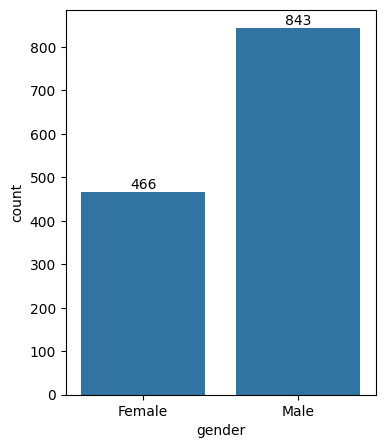

In [192]:
plt.figure(figsize=(4,5))
a=sns.countplot(df,x='gender')
a.bar_label(a.containers[0])
plt.show()

2. plot the female and male count in each pclass

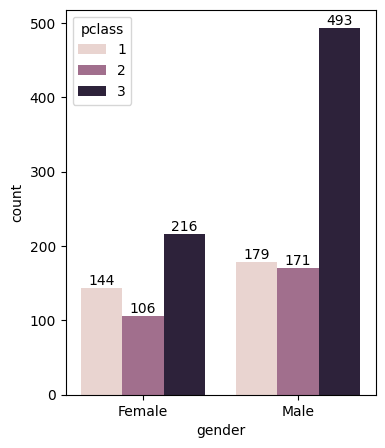

In [193]:
plt.figure(figsize=(4,5))
b=sns.countplot(df,x='gender',hue='pclass')
for i in b.containers:
    b.bar_label(i)
plt.show()

2. plot the female and male count in each survival_status

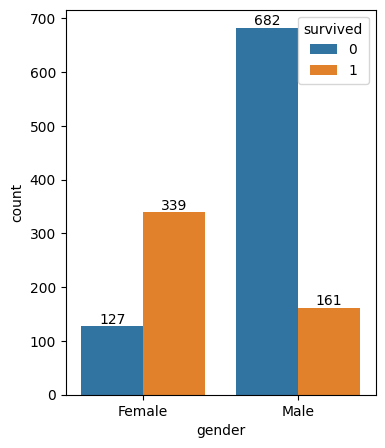

In [194]:
plt.figure(figsize=(4,5))
b=sns.countplot(df,x='gender',hue='survived')
for i in b.containers:
    b.bar_label(i)
plt.show()

1. plot the companion_type count

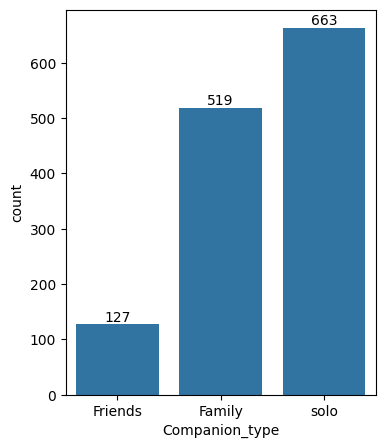

In [195]:
plt.figure(figsize=(4,5))
a=sns.countplot(df,x='Companion_type')
a.bar_label(a.containers[0])
plt.show()

1. plot the companion_type count in each gender

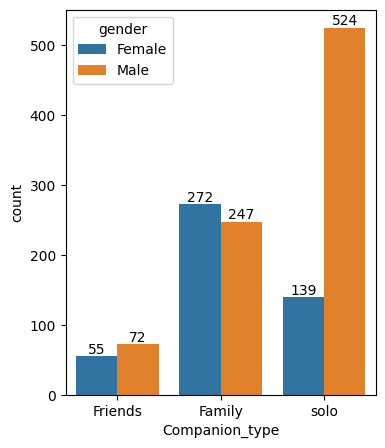

In [196]:
plt.figure(figsize=(4,5))
a=sns.countplot(df,x='Companion_type',hue='gender')
for i in a.containers:
    a.bar_label(i)
plt.show()

1. plot the companion_type count in each pclass

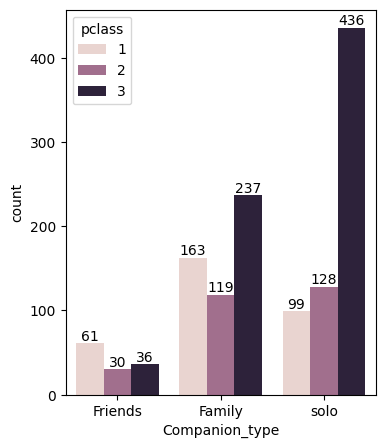

In [197]:
plt.figure(figsize=(4,5))
a=sns.countplot(df,x='Companion_type',hue='pclass')
for i in a.containers:
    a.bar_label(i)
plt.show()

1. plot the companion_type count in each survival_status

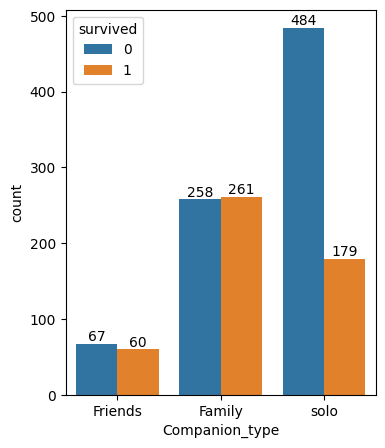

In [198]:
plt.figure(figsize=(4,5))
a=sns.countplot(df,x='Companion_type',hue='survived')
for i in a.containers:
    a.bar_label(i)
plt.show()

1. plot the age_category count in each gender


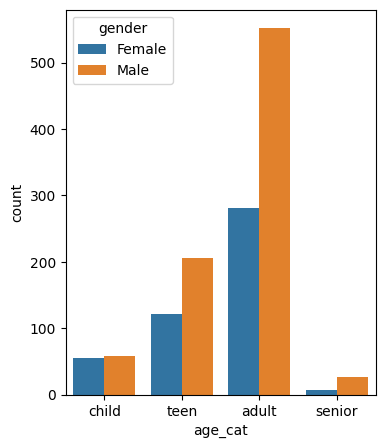

In [199]:
plt.figure(figsize=(4,5))
sns.countplot(df,x='age_cat',hue='gender')
plt.show()

1. plot the age_category count in each pclass

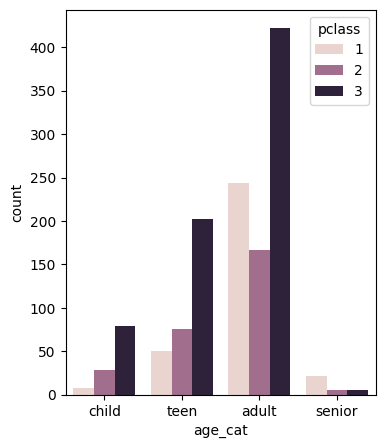

In [200]:
plt.figure(figsize=(4,5))
sns.countplot(df,x='age_cat',hue='pclass')
plt.show()

1. plot the age_category count in each survival_status


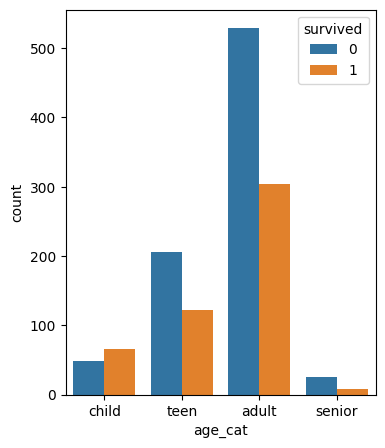

In [201]:
plt.figure(figsize=(4,5))
sns.countplot(df,x='age_cat',hue='survived')
plt.show()

1. plot the embarked count in each gender

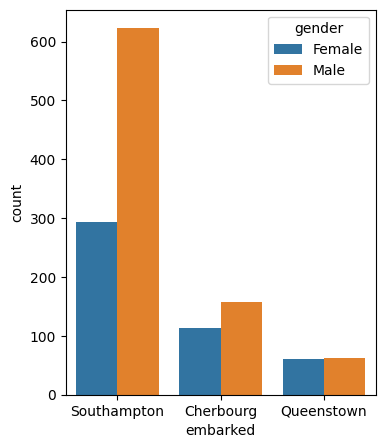

In [202]:
plt.figure(figsize=(4,5))
sns.countplot(df,x='embarked',hue='gender')
plt.show()

1. plot the embarked count in each survival_status


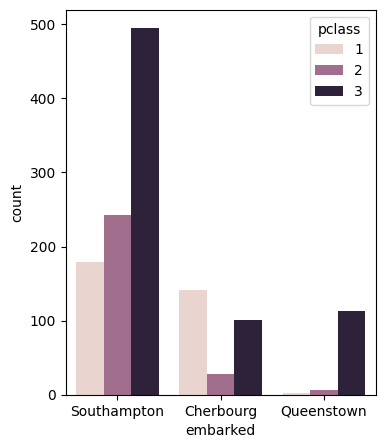

In [203]:
plt.figure(figsize=(4,5))
sns.countplot(df,x='embarked',hue='pclass')
plt.show()

1. plot the embarked count in each pclass

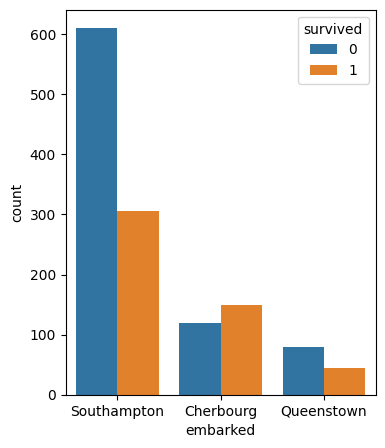

In [204]:
plt.figure(figsize=(4,5))
sns.countplot(df,x='embarked',hue='survived')
plt.show()

2. plot the distribution of fare

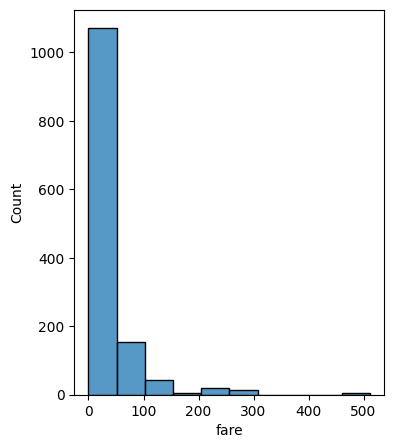

In [205]:
plt.figure(figsize=(4,5))
sns.histplot(df['fare'],bins=10)
plt.show()

3. plot the distribution of age

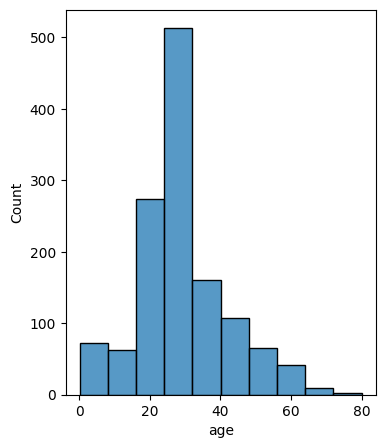

In [206]:
plt.figure(figsize=(4,5))
sns.histplot(df['age'],bins=10)
plt.show()

4. plot the percentage of passengers in each pclass

In [207]:
pclas=df['pclass'].value_counts().sort_index()
pclas


pclass
1    323
2    277
3    709
Name: count, dtype: int64

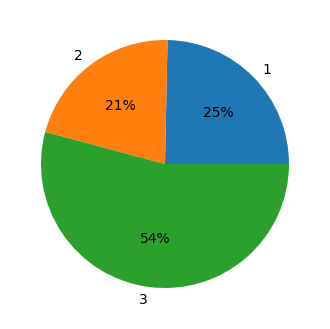

In [208]:
plt.figure(figsize=(4,5))
plt.pie(pclas,labels=pclas.index,autopct='%0.0f%%')
plt.show()

4. plot the percentage of passengers in each age_category

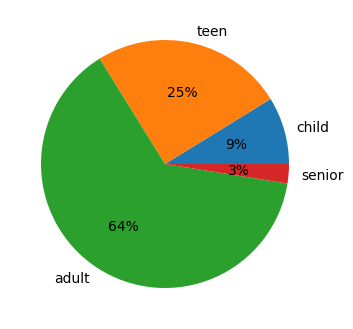

In [209]:
aa=df['age_cat'].value_counts().sort_index()
plt.figure(figsize=(4,5))
plt.pie(aa,labels=aa.index,autopct='%0.0f%%')
plt.show()

plot the spread of data in age_column wrt fare_column

<Axes: xlabel='fare', ylabel='age'>

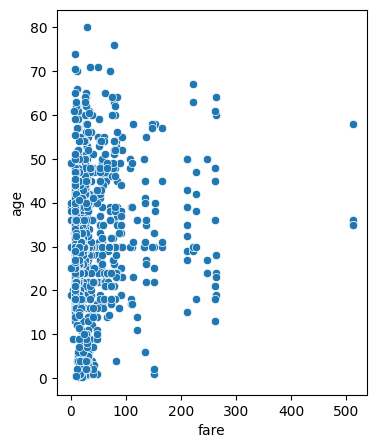

In [210]:
plt.figure(figsize=(4,5))
sns.scatterplot(df,x='fare',y='age')

plot the trend of age wrt fare

<Axes: xlabel='fare', ylabel='age'>

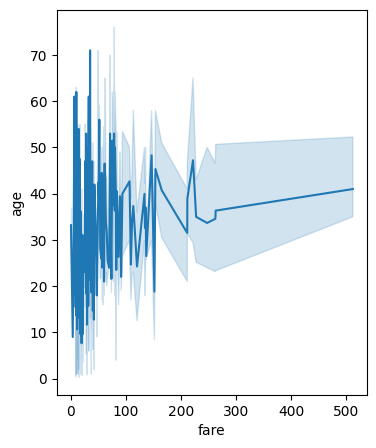

In [211]:
plt.figure(figsize=(4,5))
sns.lineplot(df,x='fare',y='age')

plot the trend of fare wrt pclass

<Axes: xlabel='pclass', ylabel='fare'>

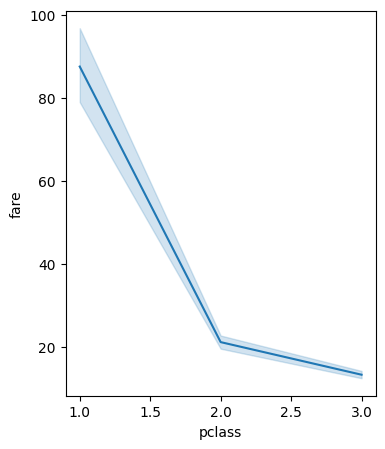

In [212]:
plt.figure(figsize=(4,5))
sns.lineplot(df,x='pclass',y='fare')

find the outlier in fare,age

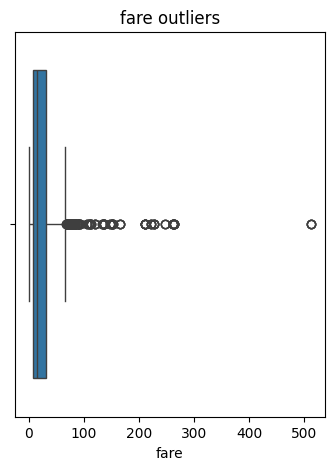

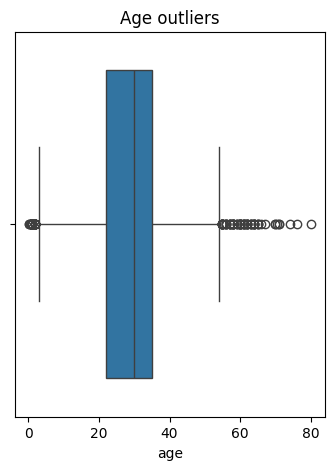

In [213]:
plt.figure(figsize=(4,5))
sns.boxplot(df,x='fare')
plt.title('fare outliers')
plt.show()
plt.figure(figsize=(4,5))
sns.boxplot(df,x='age')
plt.title('Age outliers')
plt.show()

 get the co-relation for all numerical columns using heatmap


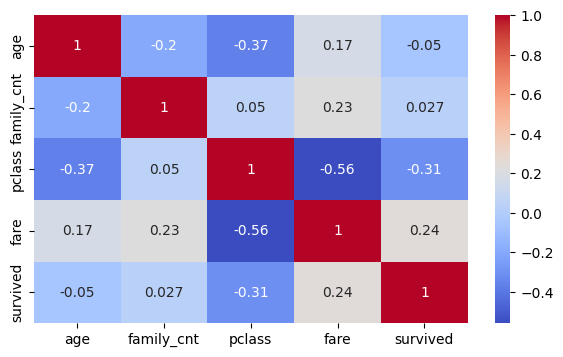

In [214]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(7,4))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

survival_rate of gender in each pclass
avg_age of gender in each pclass
avg_fare of gender in each pclass



survival_rate of gender in each age_category
survival_rate of companion_type in each age_category
